### 1. Setup and Data Acquisition


In [11]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import requests
import os

# Configuration
URL = "https://www.dropbox.com/scl/fi/0p58xa6tjumv7b327cajm/monterrey_intervention_sequence.gpkg?rlkey=3smmbcbay3fpyfdqcjxsrj7s6&dl=1"
FILENAME = "monterrey_intervention_sequence.gpkg"

# Download file
if not os.path.exists(FILENAME):
    print(f"Downloading {FILENAME}...")
    response = requests.get(URL)
    with open(FILENAME, "wb") as f:
        f.write(response.content)

# Load data
gdf = gpd.read_file(FILENAME)

# Data Inspection
print("--- Data Inspection ---")
print(f"Layer count: {len(gdf)}")
print(f"Columns: {gdf.columns.tolist()}")
print(f"Geometry type: {gdf.geometry.type.unique()}")
print(f"Original CRS: {gdf.crs}")
print(f"Intervention Order Range: {gdf['intervention_order'].min()} to {gdf['intervention_order'].max()}")

# Check for duplicates or missing values
dups = gdf['intervention_order'].duplicated().sum()
missing = gdf['intervention_order'].isnull().sum()
print(f"Duplicated intervention_order values: {dups}")
print(f"Missing intervention_order values: {missing}")

if len(gdf) != 50:
    print(f"Warning: Expected 50 records, found {len(gdf)}.")

# Sorting
gdf = gdf.sort_values('intervention_order').reset_index(drop=True)

--- Data Inspection ---
Layer count: 50
Columns: ['intervention_order', 'geometry']
Geometry type: ['Polygon']
Original CRS: EPSG:32614
Intervention Order Range: 1 to 50
Duplicated intervention_order values: 0
Missing intervention_order values: 0


### 2. Spatial Preprocessing


In [12]:
# Handle Geometries: Use centroids for polygons
gdf['geometry'] = gdf.geometry.centroid

# Coordinate Reference System (CRS) management
# Monterrey is in UTM Zone 14N (EPSG:32614)
UTM_MONTERREY = "EPSG:32614"

if gdf.crs is not None and gdf.crs.is_projected:
    print(f"Using existing projected CRS: {gdf.crs}")
else:
    print(f"Reprojecting to {UTM_MONTERREY} for metric calculations.")
    gdf = gdf.to_crs(UTM_MONTERREY)

# Add Lat/Lon columns for reporting
gdf_wgs84 = gdf.to_crs("EPSG:4326")
gdf['longitude'] = gdf_wgs84.geometry.x
gdf['latitude'] = gdf_wgs84.geometry.y

Using existing projected CRS: EPSG:32614


### 3 Test 1. Nearest Previous Intervention Calculation
We compute $d_t = \min_{j<t} d(i_t, i_j)$ for all $t > 1$.

In [13]:
distances = []
nearest_order = []

for i, row in gdf.iterrows():
    if i == 0:
        distances.append(np.nan)
        nearest_order.append(np.nan)
        continue

    # Previous interventions
    previous_gdf = gdf.iloc[:i]

    # Calculate distances to all previous
    dists = previous_gdf.geometry.distance(row.geometry)

    min_dist = dists.min()
    idx_min = dists.idxmin()

    distances.append(min_dist)
    nearest_order.append(gdf.iloc[idx_min]['intervention_order'])

gdf['nearest_previous_distance_m'] = distances
gdf['nearest_previous_order'] = nearest_order

# Results Table
results_table = gdf[['intervention_order', 'nearest_previous_order', 'nearest_previous_distance_m', 'longitude', 'latitude']]
display(results_table.head(10))

print("--- Descriptive Statistics ---")
print(gdf['nearest_previous_distance_m'].describe())

,intervention_order,nearest_previous_order,nearest_previous_distance_m,longitude,latitude
0,1,NaN,NaN,-100.392605,25.797382
1,2,1.0,2185.749299,-100.408149,25.783549
2,3,2.0,6805.328794,-100.355357,25.744956
3,4,2.0,1879.494613,-100.426831,25.782195
4,5,3.0,21767.234551,-100.178528,25.631159
5,6,1.0,6726.626197,-100.371577,25.855051
6,7,4.0,13711.673858,-100.563081,25.792522
7,8,1.0,1522.333735,-100.377674,25.799870
8,9,7.0,3571.764270,-100.596592,25.781603
9,10,5.0,14243.946082,-100.146860,25.756522


--- Descriptive Statistics ---
count       49.000000
mean      3551.985450
std       4495.145689
min        173.205081
25%        964.365076
50%       1645.448267
75%       3571.764270
max      21767.234551
Name: nearest_previous_distance_m, dtype: float64


### 3.1 Interval Analysis
Comparing behavior across specific iteration segments.

In [14]:
def get_interval(order):
    if 1 <= order <= 10:
        return '01-10'
    elif 11 <= order <= 20:
        return '11-20'
    elif 21 <= order <= 30:
        return '21-30'
    elif 31 <= order <= 40:
        return '31-40'
    elif 41 <= order <= 50:
        return '41-50'
    return None

gdf['interval'] = gdf['intervention_order'].apply(get_interval)

interval_order = ['01-10', '11-20', '21-30', '31-40', '41-50']
gdf['interval'] = pd.Categorical(
    gdf['interval'],
    categories=interval_order,
    ordered=True
)

interval_stats = (
    gdf.dropna(subset=['nearest_previous_distance_m', 'interval'])
       .groupby('interval', observed=True)['nearest_previous_distance_m']
       .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
)

print("--- Interval Statistics ---")
print(interval_stats)

--- Interval Statistics ---
                 mean       median          std          min           max  \
interval                                                                     
01-10     8046.016822  6726.626197  7044.608041  1522.333735  21767.234551   
11-20     3611.879936  2095.478553  3509.482920   708.872344  10496.070693   
21-30     2715.140805  1418.018179  3369.802237   433.012702  11140.803382   
31-40     1948.861514  1581.423679  1448.539034   779.422863   5593.076077   
41-50     1887.431311   958.496510  3312.367909   173.205081  11283.948777   

          count  
interval         
01-10         9  
11-20        10  
21-30        10  
31-40        10  
41-50        10  


### 3.2 Statistical Testing
We perform correlation tests and an OLS regression to quantify the relationship between intervention order and proximity.

In [15]:
# Prepare data for testing (drop the first row which has no distance)
test_df = gdf.dropna(subset=['nearest_previous_distance_m'])

# Correlations
pearson_r, p_p = stats.pearsonr(test_df['intervention_order'], test_df['nearest_previous_distance_m'])
spearman_r, p_s = stats.spearmanr(test_df['intervention_order'], test_df['nearest_previous_distance_m'])

# OLS Regression
X = sm.add_constant(test_df['intervention_order'])
y = test_df['nearest_previous_distance_m']
model = sm.OLS(y, X).fit()

print(f"Pearson Correlation: {pearson_r:.4f} (p={p_p:.4f})")
print(f"Spearman Rank Correlation: {spearman_r:.4f} (p={p_s:.4f})")
print("\n--- OLS Regression Summary ---")
print(model.summary())

Pearson Correlation: -0.4278 (p=0.0022)
Spearman Rank Correlation: -0.5404 (p=0.0001)

--- OLS Regression Summary ---
                                 OLS Regression Results                                
Dep. Variable:     nearest_previous_distance_m   R-squared:                       0.183
Model:                                     OLS   Adj. R-squared:                  0.166
Method:                          Least Squares   F-statistic:                     10.53
Date:                         Mon, 13 Jul 2026   Prob (F-statistic):            0.00217
Time:                                 04:25:26   Log-Likelihood:                -476.20
No. Observations:                           49   AIC:                             956.4
Df Residuals:                               47   BIC:                             960.2
Df Model:                                    1                                         
Covariance Type:                     nonrobust                                         
  

### 3.3 Visualization and Export
Generating the required plots and saving the processed data.

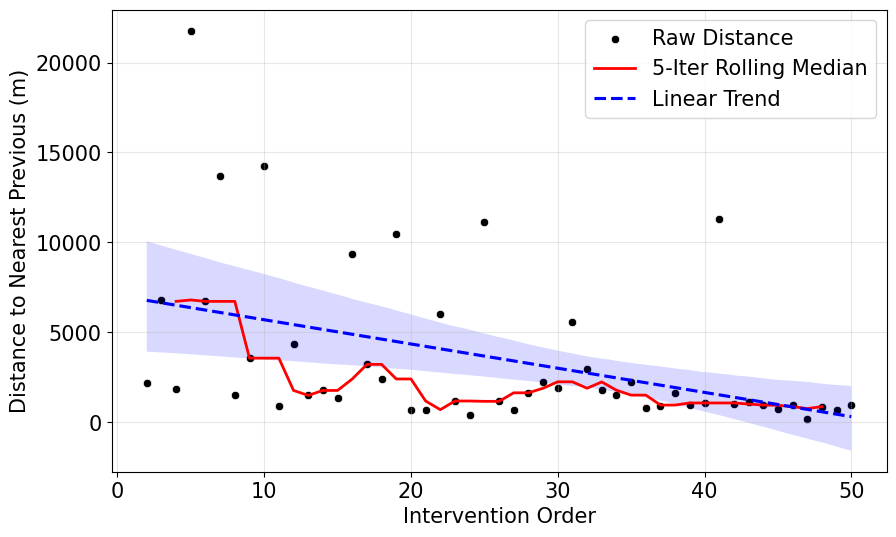

/tmp/ipykernel_761/971038904.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gdf.dropna(subset=['interval']), x='interval', y='nearest_previous_distance_m', palette='Set3')


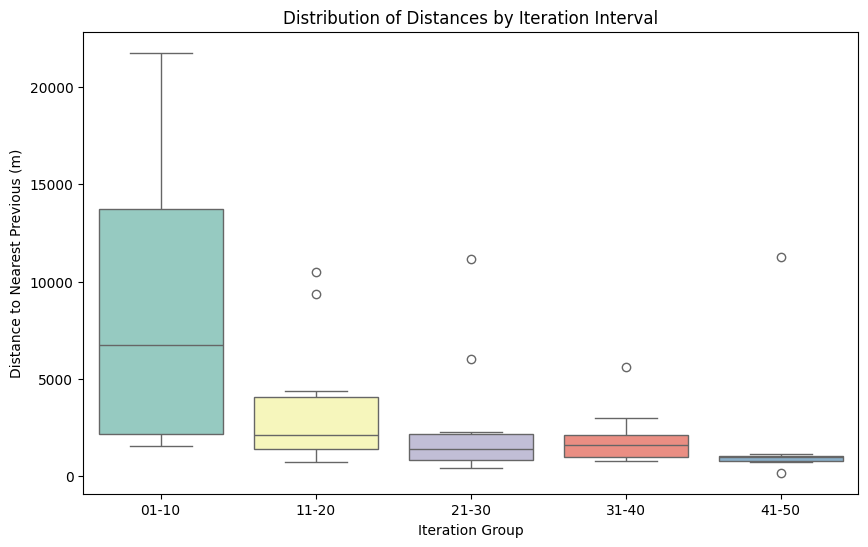

Files saved successfully.


In [16]:
# Figure 1: Distance by Intervention Order
plt.figure(figsize=(10, 6))
sns.scatterplot(data=test_df, x='intervention_order', y='nearest_previous_distance_m', color='black', label='Raw Distance')
# Rolling Median
test_df_sorted = test_df.sort_values('intervention_order')
rolling_median = test_df_sorted['nearest_previous_distance_m'].rolling(window=5, center=True).median()
plt.plot(test_df_sorted['intervention_order'], rolling_median, color='red', label='5-Iter Rolling Median', linewidth=2)
# Trendline
sns.regplot(data=test_df, x='intervention_order', y='nearest_previous_distance_m', scatter=False, color='blue', label='Linear Trend', line_kws={'linestyle':'--'})

#plt.title('Nearest Previous Intervention Distance by Order')
plt.xlabel('Intervention Order',fontsize=15)
plt.ylabel('Distance to Nearest Previous (m)',fontsize=15)
plt.legend()
plt.legend(fontsize=15)
# Tick labels larger
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.grid(True, alpha=0.3)
plt.savefig('monterrey_nearest_previous_distance.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Distribution by Interval
plt.figure(figsize=(10, 6))
sns.boxplot(data=gdf.dropna(subset=['interval']), x='interval', y='nearest_previous_distance_m', palette='Set3')
plt.title('Distribution of Distances by Iteration Interval')
plt.xlabel('Iteration Group')
plt.ylabel('Distance to Nearest Previous (m)')
plt.savefig('monterrey_distance_by_iteration_group.png', dpi=300, bbox_inches='tight')
plt.show()

# Exporting Data
gdf.to_file('monterrey_intervention_sequence_with_distances.gpkg', driver='GPKG')
gdf.to_csv('monterrey_intervention_sequence_with_distances.csv', index=False)
print("Files saved successfully.")

## 4 Test 2: Influence Region Overlap Analysis
**Objective:** Quantify whether the overlap between influence regions increases as the intervention order progresses, validating the theoretical mechanism of the OMGL framework.

Influence Radius $\delta = 1200$ m.

In [17]:
import shapely.ops as ops

# 1. Configuration
INFLUENCE_RADIUS_M = 1200

# 2. Generate Buffers
# Note: gdf is already in EPSG:32614 (metric)
gdf_buffers = gdf.copy()
gdf_buffers['buffer_geom'] = gdf_buffers.geometry.buffer(INFLUENCE_RADIUS_M)

overlap_ratios = []

# 3. Compute Sequential Overlap Ratio
for i, row in gdf_buffers.iterrows():
    if i == 0:
        overlap_ratios.append(0.0) # First intervention has 0 overlap by definition
        continue

    current_buffer = row['buffer_geom']
    previous_buffers_union = gdf_buffers.iloc[:i]['buffer_geom'].unary_union

    intersection_area = current_buffer.intersection(previous_buffers_union).area
    total_buffer_area = current_buffer.area

    ratio = intersection_area / total_buffer_area
    overlap_ratios.append(ratio)

gdf['overlap_ratio'] = overlap_ratios

# Prepare reporting table
overlap_results = gdf[['intervention_order', 'overlap_ratio', 'longitude', 'latitude']]
print("--- Overlap Ratio Results (First 10) ---")
display(overlap_results.head(10))

--- Overlap Ratio Results (First 10) ---


/tmp/ipykernel_761/2429336348.py:20: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  previous_buffers_union = gdf_buffers.iloc[:i]['buffer_geom'].unary_union


,intervention_order,overlap_ratio,longitude,latitude
0,1,0.000000,-100.392605,25.797382
1,2,0.031206,-100.408149,25.783549
2,3,0.000000,-100.355357,25.744956
3,4,0.116724,-100.426831,25.782195
4,5,0.000000,-100.178528,25.631159
5,6,0.000000,-100.371577,25.855051
6,7,0.000000,-100.563081,25.792522
7,8,0.249891,-100.377674,25.799870
8,9,0.000000,-100.596592,25.781603
9,10,0.000000,-100.146860,25.756522


### 4.1 Statistical Testing (Overlap Ratio)
Quantifying the relationship between intervention order and the accumulation of influence overlap.

In [18]:
# Correlations
pearson_r_ov, p_p_ov = stats.pearsonr(gdf['intervention_order'], gdf['overlap_ratio'])
spearman_r_ov, p_s_ov = stats.spearmanr(gdf['intervention_order'], gdf['overlap_ratio'])

# OLS Regression
X_ov = sm.add_constant(gdf['intervention_order'])
y_ov = gdf['overlap_ratio']
model_ov = sm.OLS(y_ov, X_ov).fit()

print(f"Pearson Correlation: {pearson_r_ov:.4f} (p={p_p_ov:.4f})")
print(f"Spearman Rank Correlation: {spearman_r_ov:.4f} (p={p_s_ov:.4f})")
print("\n--- OLS Regression Summary (Overlap Ratio) ---")
print(model_ov.summary())

Pearson Correlation: 0.5800 (p=0.0000)
Spearman Rank Correlation: 0.5858 (p=0.0000)

--- OLS Regression Summary (Overlap Ratio) ---
                            OLS Regression Results                            
Dep. Variable:          overlap_ratio   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.323
Method:                 Least Squares   F-statistic:                     24.33
Date:                Mon, 13 Jul 2026   Prob (F-statistic):           1.01e-05
Time:                        04:25:29   Log-Likelihood:                -2.7600
No. Observations:                  50   AIC:                             9.520
Df Residuals:                      48   BIC:                             13.34
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025    

### 4.2 Interval Analysis and Visualization

--- Overlap Ratio Interval Statistics ---
              mean    median       std  min       max  count
interval                                                    
01-10     0.039782  0.000000  0.082474  0.0  0.249891     10
11-20     0.195849  0.075972  0.250446  0.0  0.629183     10
21-30     0.353076  0.326036  0.331588  0.0  0.812952     10
31-40     0.295194  0.226369  0.282291  0.0  0.853968     10
41-50     0.627807  0.675350  0.279991  0.0  0.926114     10


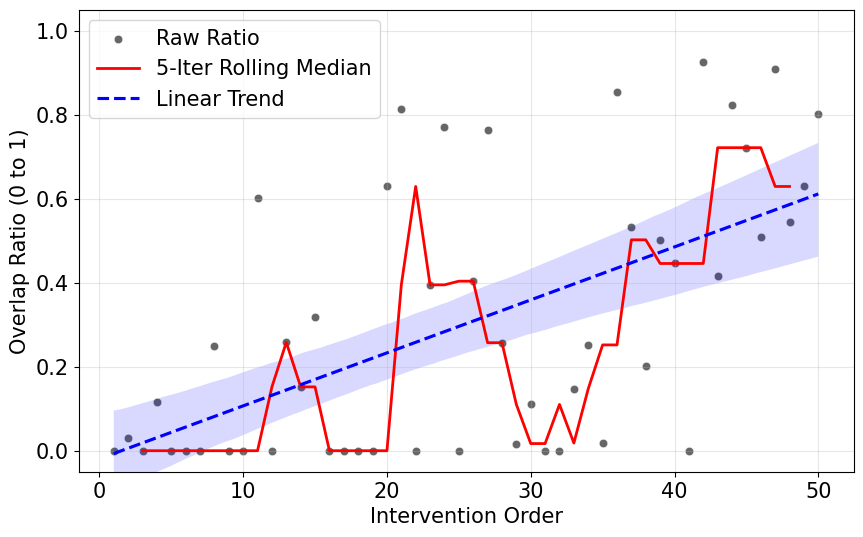

Data exported to monterrey_overlap_analysis.csv


In [19]:
# Interval Statistics
interval_stats_ov = (
    gdf.groupby('interval', observed=True)['overlap_ratio']
       .agg(['mean', 'median', 'std', 'min', 'max', 'count'])
)

print("--- Overlap Ratio Interval Statistics ---")
print(interval_stats_ov)

# Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(data=gdf, x='intervention_order', y='overlap_ratio', color='black', alpha=0.6, label='Raw Ratio')

# Rolling Median
rolling_median_ov = gdf['overlap_ratio'].rolling(window=5, center=True).median()
plt.plot(gdf['intervention_order'], rolling_median_ov, color='red', linewidth=2, label='5-Iter Rolling Median')

# Linear Regression Line
sns.regplot(data=gdf, x='intervention_order', y='overlap_ratio', scatter=False, color='blue',
            label='Linear Trend', line_kws={'linestyle':'--'})

#plt.title('Influence Region Overlap Ratio by Intervention Order (Radius = 1200m)', fontsize=16)
plt.xlabel('Intervention Order', fontsize=15)
plt.ylabel('Overlap Ratio (0 to 1)', fontsize=15)
plt.ylim(-0.05, 1.05)
# Legend with larger font size
plt.legend(fontsize=15)
# Tick labels larger
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.grid(True, alpha=0.3)
plt.savefig('monterrey_overlap_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

# Export CSV
gdf[['intervention_order', 'overlap_ratio', 'longitude', 'latitude']].to_csv('monterrey_overlap_analysis.csv', index=False)
print("Data exported to monterrey_overlap_analysis.csv")

In [20]:
test_overlap = gdf.loc[gdf['intervention_order'] > 1].copy()

pearson_r_ov, p_p_ov = stats.pearsonr(
    test_overlap['intervention_order'],
    test_overlap['overlap_ratio']
)

spearman_r_ov, p_s_ov = stats.spearmanr(
    test_overlap['intervention_order'],
    test_overlap['overlap_ratio']
)

X_ov = sm.add_constant(test_overlap['intervention_order'])
model_ov = sm.OLS(test_overlap['overlap_ratio'], X_ov).fit()

print(f"Pearson Correlation: {pearson_r_ov:.4f} (p={p_p_ov:.4f})")
print(f"Spearman Rank Correlation: {spearman_r_ov:.4f} (p={p_s_ov:.4f})")

print("\n--- OLS Regression Summary (Overlap Ratio, Orders 2-50) ---")
print(model_ov.summary())

interval_stats_ov = (
    test_overlap.groupby('interval', observed=True)['overlap_ratio']
    .agg(['mean','median','std','min','max','count'])
)

print("\n--- Interval Statistics (Orders 2-50) ---")
print(interval_stats_ov)


Pearson Correlation: 0.5688 (p=0.0000)
Spearman Rank Correlation: 0.5706 (p=0.0000)

--- OLS Regression Summary (Overlap Ratio, Orders 2-50) ---
                            OLS Regression Results                            
Dep. Variable:          overlap_ratio   R-squared:                       0.324
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     22.48
Date:                Mon, 13 Jul 2026   Prob (F-statistic):           2.00e-05
Time:                        04:25:30   Log-Likelihood:                -3.1994
No. Observations:                  49   AIC:                             10.40
Df Residuals:                      47   BIC:                             14.18
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|   